# MLP from scratch
- Input 784 -> hidden 256 -> output 10
- Each connection need 1 weight matrix + 1 bias vector

In [1]:
import torch 
from torch import nn

In [2]:
num_inputs = 784
num_hidden = 256
num_output = 10 

In [3]:
# L1
W1 = nn.Parameter(torch.randn(num_inputs,num_hidden)*0.01)
b1 = nn.Parameter(torch.zeros(num_hidden))

# L2
W2 = nn.Parameter(torch.randn(num_hidden,num_output)*0.01)
b2 = nn.Parameter(torch.zeros(num_output))

params = [W1,b1,W2,b2]

- nhân với $0.01$ để trọng số giữ ở mức nhỏ vừa đủ 
- cũng được gọi là nhân $\sigma$ - sigma để trọng số nhỏ, gần 0 -> output ban đầu gần với vùng nhạy của activation -> gradient tốt 

```py
nn.Parameter = {torch.tensor + require_grad = true} # và tự tính gradient khi backward

```

- nếu khởi tạo weight = 0 -> tất cả neuron giống hệt nhau -> cần `randn` để phá đối xứng
- Bias = 0, nhưng bias dịch chuyển theo output -> 0 vấn đề gì  

In [4]:
def relu(X):
    return torch.max(X,torch.zeros_like(X))

- dùng `zero-like(X)` để tạo tensor cùng shape 

In [5]:
def forward(X):
    X = X.reshape(-1, num_inputs) 

    H = relu(X@W1 + b1)

    O = H@W+b2

    return O

Output trả về **logit** - giá trị thô 

In [6]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# ====== DATA ======
trans = transforms.Compose([transforms.ToTensor()])
train_data = torchvision.datasets.FashionMNIST(
    './.data', train=True, transform=trans, download=True)
test_data = torchvision.datasets.FashionMNIST(
    './.data', train=False, transform=trans, download=True)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)

# ====== PARAMETERS ======
num_inputs, num_hiddens, num_outputs = 784, 256, 10
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens))
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs))
params = [W1, b1, W2, b2]

# ====== ReLU ======
def relu(X):
    return torch.max(X, torch.zeros_like(X))

# ====== FORWARD ======
def forward(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X @ W1 + b1)
    return H @ W2 + b2

# ====== TRAIN ======
lr = 0.1
for epoch in range(10):
    for X, y in train_loader:
        loss = F.cross_entropy(forward(X), y)
        loss.backward()
        with torch.no_grad():
            for param in params:
                param -= lr * param.grad    # SGD update
                param.grad.zero_()          # Zero gradients
    
    # Evaluate
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            correct += (forward(X).argmax(1) == y).sum().item()
            total += y.shape[0]
    print(f"Epoch {epoch+1:2d} | Test Acc: {correct/total:.4f}")

Epoch  1 | Test Acc: 0.7187
Epoch  2 | Test Acc: 0.8048
Epoch  3 | Test Acc: 0.8033
Epoch  4 | Test Acc: 0.7464
Epoch  5 | Test Acc: 0.8199
Epoch  6 | Test Acc: 0.8382
Epoch  7 | Test Acc: 0.8061
Epoch  8 | Test Acc: 0.8148
Epoch  9 | Test Acc: 0.8487
Epoch 10 | Test Acc: 0.8510


---

# MLP concise

In [7]:
import torch
from torch import nn


model = nn.Sequential(
    nn.Flatten(),
    nn.LazyLinear(256),
    nn.ReLU(),
    nn.LazyLinear(10)
)

In [8]:
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)

In [9]:
for epoch in range(10):
    model.train()
    for X, y in train_loader:
        loss = F.cross_entropy(model(X), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Evaluate
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            correct += (model(X).argmax(1) == y).sum().item()
            total += y.shape[0]
    print(f"Epoch {epoch+1:2d} | Test Acc: {correct/total:.4f}")

Epoch  1 | Test Acc: 0.7242
Epoch  2 | Test Acc: 0.7587
Epoch  3 | Test Acc: 0.8159
Epoch  4 | Test Acc: 0.8291
Epoch  5 | Test Acc: 0.8194
Epoch  6 | Test Acc: 0.8385
Epoch  7 | Test Acc: 0.8435
Epoch  8 | Test Acc: 0.8532
Epoch  9 | Test Acc: 0.8517
Epoch 10 | Test Acc: 0.8519


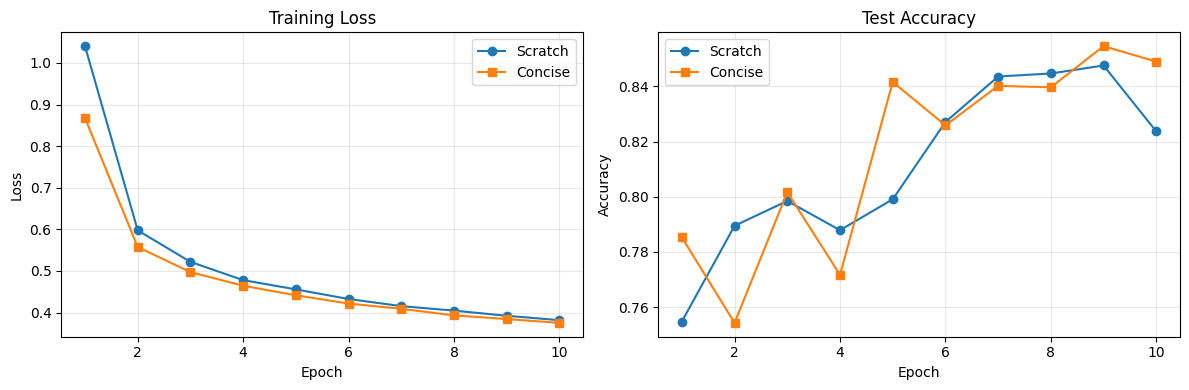

In [10]:
import matplotlib.pyplot as plt
import torch
from torch import nn
epochs = 10
lr = 0.1

def evaluate_accuracy(predict_fn, data_loader):
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in data_loader:
            pred = predict_fn(X).argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.shape[0]
    return correct / total

# ===== 1) Scratch MLP (re-init for fair comparison) =====
W1_s = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)
b1_s = nn.Parameter(torch.zeros(num_hiddens))
W2_s = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)
b2_s = nn.Parameter(torch.zeros(num_outputs))
params_s = [W1_s, b1_s, W2_s, b2_s]

def forward_scratch(X):
    X = X.reshape(-1, num_inputs)
    H = relu(X @ W1_s + b1_s)
    return H @ W2_s + b2_s

scratch_losses, scratch_accs = [], []

for epoch in range(epochs):
    loss_sum, n_batches = 0.0, 0
    for X, y in train_loader:
        loss = F.cross_entropy(forward_scratch(X), y)
        loss.backward()
        with torch.no_grad():
            for p in params_s:
                p -= lr * p.grad
                p.grad.zero_()
        loss_sum += loss.item()
        n_batches += 1

    scratch_losses.append(loss_sum / n_batches)
    scratch_accs.append(evaluate_accuracy(forward_scratch, test_loader))

# ===== 2) Concise MLP (re-init for fair comparison) =====
model_c = nn.Sequential(
    nn.Flatten(),
    nn.LazyLinear(256),
    nn.ReLU(),
    nn.LazyLinear(10)
)
optimizer_c = torch.optim.SGD(model_c.parameters(), lr=lr)

concise_losses, concise_accs = [], []

for epoch in range(epochs):
    model_c.train()
    loss_sum, n_batches = 0.0, 0
    for X, y in train_loader:
        loss = F.cross_entropy(model_c(X), y)
        optimizer_c.zero_grad()
        loss.backward()
        optimizer_c.step()
        loss_sum += loss.item()
        n_batches += 1

    concise_losses.append(loss_sum / n_batches)
    model_c.eval()
    concise_accs.append(evaluate_accuracy(model_c, test_loader))

# ===== Plot training process =====
ep = range(1, epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, scratch_losses, marker='o', label='Scratch')
axes[0].plot(ep, concise_losses, marker='s', label='Concise')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(ep, scratch_accs, marker='o', label='Scratch')
axes[1].plot(ep, concise_accs, marker='s', label='Concise')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()